## Deep FM model for Search Relevance Ranking

In [61]:
import pickle
import cloudpickle
from tqdm import tqdm
import random

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample

import torch
from torch.utils.data import Dataset, DataLoader

import json
from datetime import datetime

from deepctr_torch.models import DeepFM
from deepctr_torch.inputs import SparseFeat, DenseFeat, get_feature_names


In [62]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

## Data Loading & Preparation

In [63]:
df = pd.read_pickle('df_features.pkl')
print(df.shape)
print(df.dtypes)
print(df.memory_usage(deep=True).sum() / 1e6, "MB")

(54281, 18)
answers                 object
passages                object
query                      str
query_id                 int32
query_type                 str
wellFormedAnswers       object
passage_text               str
is_selected             object
label                    int64
query_length             int64
passage_length           int64
length_ratio           float64
exact_match              int64
query_term_coverage    float64
jaccard_similarity     float64
tfidf_cosine_sim       float64
bm25_score             float64
passage_position         int64
dtype: object
50.841565 MB


### Features

In [64]:

df['query_type_encoded'] = LabelEncoder().fit_transform(df['query_type'].astype(str))

In [65]:
# Columns not to use as features: query, passage_text. passages, answers, wellFormedanswers, is_selected
# Columns to keep but not as features: query_id, label

# Dense Feat - continuous or numerical features
# Sparse Features - categorical features

dense_features = [
    'query_length',
    'passage_length',
    'length_ratio',
    'exact_match',
    'query_term_coverage',
    'jaccard_similarity',
    'tfidf_cosine_sim',
    'bm25_score',
    'passage_position'
]

sparse_features = [
  'query_type_encoded'
]

In [66]:
scaler = StandardScaler()
df[dense_features] = scaler.fit_transform(df[dense_features])

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [67]:
fixlen_feature_columns = (
    [SparseFeat(feat, vocabulary_size=df[feat].nunique() + 1, embedding_dim=4) for feat in sparse_features] 
    +
    [DenseFeat(feat) for feat in dense_features]
)

feature_names = get_feature_names(fixlen_feature_columns)
print(f"Feature Names: {feature_names}")

Feature Names: ['query_type_encoded', 'query_length', 'passage_length', 'length_ratio', 'exact_match', 'query_term_coverage', 'jaccard_similarity', 'tfidf_cosine_sim', 'bm25_score', 'passage_position']


### Tran Test Split

In [68]:

# unique_queries = df['query_id'].unique()

# train_query_ids, test_query_ids = train_test_split(
#     unique_queries,
#     test_size=0.2,
#     random_state=42
# )


# train_df = df[df['query_id'].isin(train_query_ids)].reset_index(drop=True)
# test_df  = df[df['query_id'].isin(test_query_ids)].reset_index(drop=True)

# print(f"Train: {len(train_df):,} rows | {train_df['query_id'].nunique():,} queries")
# print(f"Test:  {len(test_df):,} rows  | {test_df['query_id'].nunique():,} queries")
# print(f"Avg passages per query — Train: {len(train_df)/train_df['query_id'].nunique():.1f}")
# print(f"Avg passages per query — Test:  {len(test_df)/test_df['query_id'].nunique():.1f}")


# print(f"\nPositive rate — Train: {train_df['label'].mean():.4f} | Test: {test_df['label'].mean():.4f}")

In [69]:
unique_qids = df['query_id'].unique()

train_qids, temp_qids = train_test_split(unique_qids, test_size=0.30, random_state=42)
val_qids, test_qids   = train_test_split(temp_qids,   test_size=0.50, random_state=42)

train_df = df[df['query_id'].isin(train_qids)].reset_index(drop=True)
val_df   = df[df['query_id'].isin(val_qids)].reset_index(drop=True)
test_df  = df[df['query_id'].isin(test_qids)].reset_index(drop=True)

### Preparing Input in Deepctr Torch Format


In [70]:
# def build_input(data, feature_names):
#     return {name: data[name].values for name in feature_names}

# train_input = build_input(train_df, feature_names)
# test_input  = build_input(test_df, feature_names)

# y_train = train_df['label'].values.astype(np.float32)
# y_test  = test_df['label'].values.astype(np.float32)

# neg = (df['label'] == 0).sum()
# pos = (df['label'] == 1).sum()
# pos_weight = neg / pos
# print(f"Positive weight: {pos_weight:.2f}")  # should be ~8.3

# sample_weights = np.where(y_train == 1, pos_weight, 1.0)

In [71]:
# Build inputs
def build_input(data, feature_names):
    return {name: data[name].values for name in feature_names}

train_input = build_input(train_df, feature_names)
val_input   = build_input(val_df,   feature_names)
test_input  = build_input(test_df,  feature_names)

y_train = train_df['label'].values.astype(np.float32)
y_val   = val_df['label'].values.astype(np.float32)
y_test  = test_df['label'].values.astype(np.float32)


In [72]:

# def build_input(data, feature_names):
#     return {name: data[name].values for name in feature_names}

# # Separate majority and minority classes
# train_majority = train_df[train_df['label'] == 0]
# train_minority = train_df[train_df['label'] == 1]

# print(f"Before — Majority: {len(train_majority):,} | Minority: {len(train_minority):,}")

# # Oversample minority to match majority
# train_minority_upsampled = resample(
#     train_minority,
#     replace=True,              # sample with replacement
#     n_samples=len(train_majority),
#     random_state=42
# )

# # Combine and shuffle
# train_balanced = pd.concat([train_majority, train_minority_upsampled])
# train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# print(f"After  — Majority: {(train_balanced['label']==0).sum():,} | Minority: {(train_balanced['label']==1).sum():,}")

# # Rebuild train input from balanced df
# train_input = build_input(train_balanced, feature_names)
# y_train = train_balanced['label'].values.astype(np.float32)

# test_input = build_input(test_df, feature_names)
# y_test = test_df['label'].values.astype(np.float32)

## DeepFM Model

In [73]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = DeepFM(
    linear_feature_columns=fixlen_feature_columns,
    dnn_feature_columns=fixlen_feature_columns,
    dnn_hidden_units=(128, 64, 32),
    # dnn_hidden_units =  (64, 32),
    dnn_dropout=0.3,
    task='binary',
    device=device
)

model.compile(
    optimizer='adam',
    # optimizer='adagrad', 
    loss='binary_crossentropy',
    metrics = ['binary_crossentropy', 'auc']
)

print(model)

Using device: cpu
DeepFM(
  (embedding_dict): ModuleDict(
    (query_type_encoded): Embedding(6, 4)
  )
  (linear_model): Linear(
    (embedding_dict): ModuleDict(
      (query_type_encoded): Embedding(6, 1)
    )
  )
  (out): PredictionLayer()
  (fm): FM()
  (dnn): DNN(
    (dropout): Dropout(p=0.3, inplace=False)
    (linears): ModuleList(
      (0): Linear(in_features=13, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
    (activation_layers): ModuleList(
      (0-2): 3 x ReLU(inplace=True)
    )
  )
  (dnn_linear): Linear(in_features=32, out_features=1, bias=False)
)


### Model Training

In [74]:
history = model.fit(
    train_input, 
    y_train,
    batch_size=256,
    epochs = 20,
    # validation_split = 0.1,
    validation_data=(val_input, y_val),
    verbose = 1
)

torch.save(model.state_dict(), 'deepfm_best.pt')
print("Model saved to deepfm_best.pt")

cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch


149it [00:01, 87.43it/s]


Epoch 1/20
1s - loss:  0.4044 - binary_crossentropy:  0.4040 - auc:  0.6396 - val_binary_crossentropy:  0.3241 - val_auc:  0.6709


149it [00:01, 141.46it/s]


Epoch 2/20
1s - loss:  0.3205 - binary_crossentropy:  0.3207 - auc:  0.6818 - val_binary_crossentropy:  0.3224 - val_auc:  0.6738


...

Epoch 18/20
1s - loss:  0.3192 - binary_crossentropy:  0.3193 - auc:  0.6872 - val_binary_crossentropy:  0.3215 - val_auc:  0.6773


149it [00:01, 86.47it/s] 


Epoch 19/20
1s - loss:  0.3193 - binary_crossentropy:  0.3194 - auc:  0.6878 - val_binary_crossentropy:  0.3212 - val_auc:  0.6777


149it [00:01, 97.03it/s] 


Epoch 20/20
1s - loss:  0.3190 - binary_crossentropy:  0.3192 - auc:  0.6883 - val_binary_crossentropy:  0.3216 - val_auc:  0.6762
Model saved to deepfm_best.pt


### Model Evaluation - Ranking Metrics

In [75]:
def compute_ndcg_at_k(df_eval, preds, k = 10):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ncdg_scores = []

    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values 

        # Discounted Cumulative Gain
        dcg = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(relevance[:k])])
        ideal = group.sort_values('label', ascending=False)['label'].values
        idcg = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(ideal[:k])])

        if idcg > 0:
            ncdg_scores.append(dcg / idcg)
    
    return np.mean(ncdg_scores)

def compute_map(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ap_scores = []

    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values 

        if relevance.sum() == 0:
            continue 

        num_relevant = 0
        precisions = []

        for rank, rel in enumerate(relevance):
            if rel == 1:
                num_relevant += 1 
                precisions.append(num_relevant / (rank + 1))
                
        ap_scores.append(np.mean(precisions))

    return np.mean(ap_scores)


In [76]:
test_preds = model.predict(test_input, batch_size=256).flatten()

ncdg_10 = compute_ndcg_at_k(test_df, test_preds, k = 10)
map_score = compute_map(test_df, test_preds)

print("Ranking Evaluation Results")
# NDCG accounts for the graded relevance of results, providing a more nuanced understanding of Search Ranking Quality
print(f"NCDG 10 : {ncdg_10:.4f}")
print(f"MAP : {map_score:.4f}")


Ranking Evaluation Results
NCDG 10 : 0.6021
MAP : 0.4744


## Training Curves

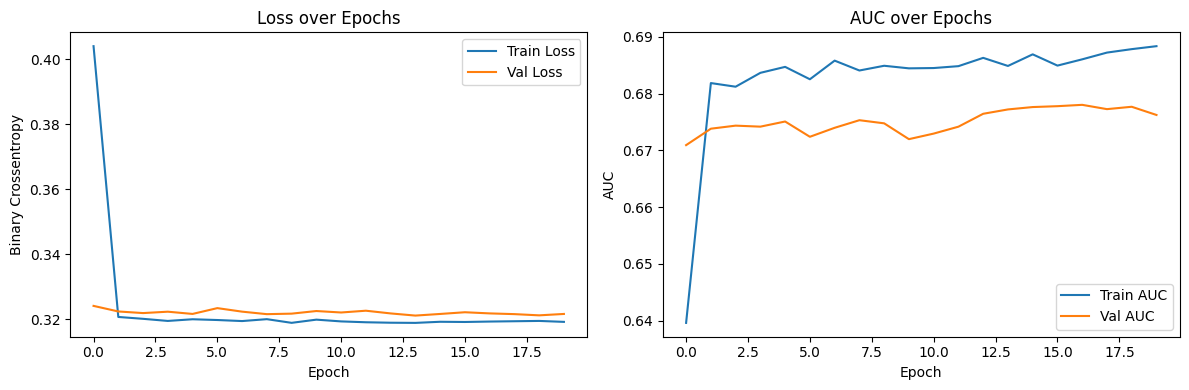

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.epoch, history.history['binary_crossentropy'], label='Train Loss')
axes[0].plot(history.epoch, history.history['val_binary_crossentropy'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

axes[1].plot(history.epoch, history.history['auc'], label='Train AUC')
axes[1].plot(history.epoch, history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

## Final Model & Artifacts

In [78]:

torch.save(model.state_dict(), 'deepfm_final.pt')


with open('feature_columns.pkl', 'wb') as f:
    cloudpickle.dump(fixlen_feature_columns, f)


model_config = {
    'dnn_hidden_units': (128, 64, 32),
    'dnn_dropout': 0.3,
    'embedding_dim': 4,
    'optimizer': 'adam',
    'epochs': 20,
    'batch_size': 256,
    'dense_features': dense_features,
    'sparse_features': sparse_features,
    'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M')
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Saved: deepfm_final.pt, feature_columns.pkl, model_config.json")

Saved: deepfm_final.pt, feature_columns.pkl, model_config.json


### Full Evaluation on Test Set

In [79]:
test_preds = model.predict(test_input, batch_size=256).flatten()

def compute_ndcg_at_k(df_eval, preds, k=10):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ndcg_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values
        dcg  = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(relevance[:k])])
        ideal = group.sort_values('label', ascending=False)['label'].values
        idcg = sum([rel / np.log2(rank + 2) for rank, rel in enumerate(ideal[:k])])
        if idcg > 0:
            ndcg_scores.append(dcg / idcg)
    return np.mean(ndcg_scores)


def compute_map(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    ap_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values

        if relevance.sum() == 0:
            continue
        num_relevant = 0
        precisions = []
        for rank, rel in enumerate(relevance):
            if rel == 1:
                num_relevant += 1
                precisions.append(num_relevant / (rank + 1))
        ap_scores.append(np.mean(precisions))
    return np.mean(ap_scores)

def compute_mrr(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    rr_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values
        for rank, rel in enumerate(relevance):
            if rel == 1:
                rr_scores.append(1 / (rank + 1))
                break
        else:
            rr_scores.append(0)
    return np.mean(rr_scores)


def compute_precision_at_k(df_eval, preds, k=10):
    df_eval = df_eval.copy()
    df_eval['pred'] = preds
    p_scores = []
    for query_id, group in df_eval.groupby('query_id'):
        group_sorted = group.sort_values('pred', ascending=False)
        relevance = group_sorted['label'].values[:k]
        p_scores.append(relevance.sum() / k)
    return np.mean(p_scores)


### Computing Metrics

In [80]:
print(f"test_preds length : {len(test_preds)}")
print(f"test_df length    : {len(test_df)}")  # must match
print(f"Unique queries in test: {test_df['query_id'].nunique()}")
print(f"Avg passages per query: {len(test_df) / test_df['query_id'].nunique():.1f}")

test_preds length : 8146
test_df length    : 8146
Unique queries in test: 816
Avg passages per query: 10.0


In [81]:
ndcg_5  = compute_ndcg_at_k(test_df, test_preds, k=5)
ndcg_10 = compute_ndcg_at_k(test_df, test_preds, k=10)
map_score = compute_map(test_df, test_preds)
mrr = compute_mrr(test_df, test_preds)
p_at_5  = compute_precision_at_k(test_df, test_preds, k=5)
p_at_10 = compute_precision_at_k(test_df, test_preds, k=10)


print("       FINAL EVALUATION RESULTS")
print(f"  NDCG@5       : {ndcg_5:.4f}")
print(f"  NDCG@10      : {ndcg_10:.4f}")
print(f"  MAP          : {map_score:.4f}")
print(f"  MRR          : {mrr:.4f}")
print(f"  Precision@5  : {p_at_5:.4f}")
print(f"  Precision@10 : {p_at_10:.4f}")


results = {
    'NDCG@5': round(ndcg_5, 4),
    'NDCG@10': round(ndcg_10, 4),
    'MAP': round(map_score, 4),
    'MRR': round(mrr, 4),
    'Precision@5': round(p_at_5, 4),
    'Precision@10': round(p_at_10, 4)
}

with open('evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n Results saved to evaluation_results.json")


       FINAL EVALUATION RESULTS
  NDCG@5       : 0.5230
  NDCG@10      : 0.6021
  MAP          : 0.4744
  MRR          : 0.4809
  Precision@5  : 0.1610
  Precision@10 : 0.1060

 Results saved to evaluation_results.json


### Training Curves

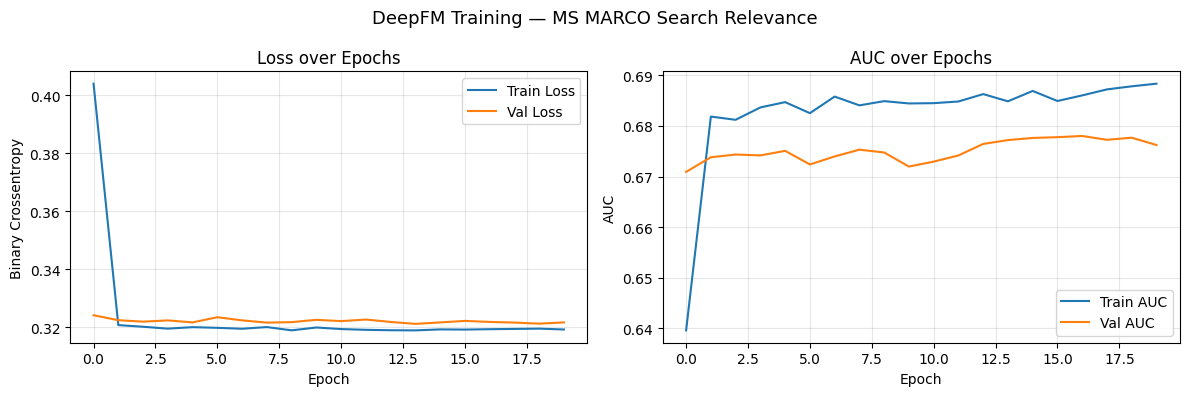

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.epoch, history.history['binary_crossentropy'], label='Train Loss')
axes[0].plot(history.epoch, history.history['val_binary_crossentropy'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.epoch, history.history['auc'], label='Train AUC')
axes[1].plot(history.epoch, history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DeepFM Training — MS MARCO Search Relevance', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Experiments Summmary

In [83]:
experiments = pd.DataFrame({
    'Run': ['Baseline', 'Oversampled', 'Wider Architecture', 'Adagrad Optimizer'],
    'Architecture': ['(64, 32)', '(64, 32)', '(128, 64, 32)', '(128, 64, 32)'],
    'Optimizer': ['Adam', 'Adam', 'Adam', 'Adagrad'],
    'Imbalance Handling': ['None', 'Oversample', 'None', 'None'],
    'NDCG@10': [0.8503, 0.8465, 0.8511, 0.8483],
    'MAP': [0.7984, 0.7935, 0.7995, 0.7958]
})

experiments['Best'] = experiments['NDCG@10'] == experiments['NDCG@10'].max()
print("\n Experiment Summary:")
print(experiments.to_string(index=False))


 Experiment Summary:
               Run  Architecture Optimizer Imbalance Handling  NDCG@10    MAP  Best
          Baseline      (64, 32)      Adam               None   0.8503 0.7984 False
       Oversampled      (64, 32)      Adam         Oversample   0.8465 0.7935 False
Wider Architecture (128, 64, 32)      Adam               None   0.8511 0.7995  True
 Adagrad Optimizer (128, 64, 32)   Adagrad               None   0.8483 0.7958 False
